# 13 - ML 信号顾问（每日操作建议）

基于 XGBoost 多 horizon 预测的目标仓位制信号顾问。

**架构：**
1. 特征构造（60 维：信号分 + 触发器 + 趋势 + composite 时序 + 原始指标）
2. 多 horizon 推理（3d / 5d / 10d 预测对数收益）
3. 决策层映射（综合得分 → 目标仓位 → 操作）
4. 风控覆盖（止盈、非对称阈值、安全边际）

**前置依赖：**
- 模型已训练并落库到 `ml_model_registry`（运行 `14_ml_training.ipynb`）
- 当日数据已通过 `09_daily_pipeline` 入库（午盘 15:00 后）

**步骤：**
1. 初始化（标的池 + 信号日期）
2. 加载 ML 模型 + 当前持仓注入
3. 生成今日操作建议
4. 操作建议表格 + 逐票归因
5. 个股走势 + 历史买卖标记
6. 写入数据库

## 1. 初始化

In [19]:
%load_ext autoreload
%autoreload 2

import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager, FontManager
import pandas as pd
import numpy as np
from datetime import datetime
from IPython.display import display

_cache_dir = matplotlib.get_cachedir()
for _f in os.listdir(_cache_dir):
    if _f.startswith('fontlist'):
        os.remove(os.path.join(_cache_dir, _f))
_fm = FontManager(); fontManager.__dict__.update(_fm.__dict__)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Sans CJK SC', 'Droid Sans Fallback']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

from invest_model.db import get_engine
from invest_model.repositories.stock_pool_repo import StockPoolRepository
from invest_model.repositories.stock_daily_repo import StockDailyRepository
from invest_model.repositories.etf_repo import ETFRepository

engine = get_engine()
pool_repo = StockPoolRepository(engine)
daily_repo = StockDailyRepository(engine)
etf_repo = ETFRepository(engine)

_core = pool_repo.get_pool('core')
_etf = pool_repo.get_pool('etf')
all_pool = pd.concat([_core, _etf], ignore_index=True)
all_codes = all_pool['code'].tolist()
code_name_map = dict(zip(all_pool['code'], all_pool['name']))

# 信号日期：取数据库已入库的最新交易日（T-1 或 T）
latest_dates = []
for c in all_codes:
    d = daily_repo.get_latest_date(code=c) or etf_repo.get_latest_date(c)
    if d:
        latest_dates.append(d)
trade_date = max(latest_dates) if latest_dates else datetime.now().strftime('%Y%m%d')
trade_date_fmt = f'{trade_date[:4]}-{trade_date[4:6]}-{trade_date[6:]}'

print('=' * 60)
print(f'  信号日期: {trade_date_fmt}')
print(f'  标的池: {len(all_codes)} 只 (core {len(_core)} + etf {len(_etf)})')
print(f'  说明: 数据库最新已入库交易日')
print(f'        如需当天数据请在收盘后运行 daily_pipeline')
print('=' * 60)
for c in all_codes:
    print(f'  {c} {code_name_map.get(c, "")}')

[autoreload of invest_model.advisor.advisor failed: Traceback (most recent call last):
  File "/home/admin/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/admin/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/admin/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/admin/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/admin/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/admin/.local/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 309, in update_function
    setattr(old, name, getattr(new, name))
ValueError: 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  信号日期: 2026-05-06
  标的池: 6 只 (core 5 + etf 1)
  说明: 数据库最新已入库交易日
        如需当天数据请在收盘后运行 daily_pipeline
  000833.SZ 粤桂股份
  002594.SZ 比亚迪
  002648.SZ 卫星化学
  300442.SZ 润泽科技
  600691.SH 潞化科技
  516120.SH 化工50ETF


## 2. 加载 ML 模型

从 `ml_model_registry` 加载逐票多 horizon 模型。

In [20]:
from invest_model.ml import list_registry, LABEL_HORIZONS

MODEL_VERSION = 'v1'

registry = list_registry(engine, codes=all_codes, version=MODEL_VERSION)
if registry.empty:
    print('⚠️ 未找到已训练的 ML 模型，请先运行 14_ml_training.ipynb')
else:
    show = registry[['code', 'horizon', 'n_samples', 'cv_avg_ic', 'cv_hit_rate', 'train_end']].copy()
    show['name'] = show['code'].map(code_name_map)
    show = show[['code', 'name', 'horizon', 'n_samples', 'cv_avg_ic', 'cv_hit_rate', 'train_end']]
    display(show.sort_values(['code', 'horizon']))

,code,name,horizon,n_samples,cv_avg_ic,cv_hit_rate,train_end
0,000833.SZ,粤桂股份,3,400,-0.02500,0.5529,20260414
1,000833.SZ,粤桂股份,5,400,0.10016,0.6630,20260410
2,000833.SZ,粤桂股份,10,400,0.25456,0.6794,20260402
3,002594.SZ,比亚迪,3,400,0.05648,0.5419,20260414
4,002594.SZ,比亚迪,5,400,0.05932,0.4682,20260410
5,002594.SZ,比亚迪,10,400,0.06126,0.4901,20260402
6,002648.SZ,卫星化学,3,400,0.00000,0.5409,20260414
7,002648.SZ,卫星化学,5,400,0.00000,0.5370,20260410
8,002648.SZ,卫星化学,10,400,0.17980,0.5856,20260402
9,300442.SZ,润泽科技,3,400,0.02851,0.5274,20260414


## 3. 当前持仓输入

**重要：** 目标仓位制需要知道当前每只票的持仓比例，才能算出 delta（应该买/卖多少）。

在生产中应从券商接口或 broker DB 读取；这里用手工字典示例。

In [21]:
current_positions = {c: 0.0 for c in all_codes}

# 示例：粤桂股份持有 30%，比亚迪持有 20%（按需修改）
# current_positions['000833.SZ'] = 0.30
# current_positions['002594.SZ'] = 0.20

print('当前持仓:')
for code, w in current_positions.items():
    print(f'  {code} {code_name_map.get(code, ""):8s} {w:.0%}')

当前持仓:
  000833.SZ 粤桂股份     0%
  002594.SZ 比亚迪      0%
  002648.SZ 卫星化学     0%
  300442.SZ 润泽科技     0%
  600691.SH 潞化科技     0%
  516120.SH 化工50ETF  0%


## 4. 生成今日操作建议

In [22]:
from invest_model.advisor import StockAdvisor
from invest_model.advisor.persistence import save_advisor_signals

advisor = StockAdvisor(engine, version=MODEL_VERSION)
signals = advisor.advise_batch(
    all_codes, trade_date, code_name_map,
    current_positions=current_positions,
)
print(f'生成 {len(signals)} 条信号')

17:48:43 | INFO    | 加载 ML 模型: 6 只标的 × 3 horizons version=v1


生成 6 条信号


## 5. 操作建议表

In [23]:
rows = []
for s in signals:
    rows.append({
        '代码': s.code,
        '名称': s.name,
        '操作': s.action_cn,
        '当前': f'{s.current_position:.0%}',
        '目标': f'{s.target_position:.0%}',
        '调仓': f'{s.delta_position:+.0%}' if abs(s.delta_position) >= 0.005 else '0%',
        'score': f'{s.horizon_score:+.4f}',
        '置信度': s.confidence,
        '安全边际': f'{s.safety_margin:.2f}',
        '止盈': '✓' if s.take_profit else '',
        'pred_3d': f'{s.sub_scores.get("pred_3d", 0):+.4f}',
        'pred_5d': f'{s.sub_scores.get("pred_5d", 0):+.4f}',
        'pred_10d': f'{s.sub_scores.get("pred_10d", 0):+.4f}',
    })
table = pd.DataFrame(rows)
display(table)

,代码,名称,操作,当前,目标,调仓,score,置信度,安全边际,止盈,pred_3d,pred_5d,pred_10d
0,000833.SZ,粤桂股份,买入,0%,12%,+12%,+0.0408,100,0.26,,+0.0300,+0.0424,+0.0532
1,300442.SZ,润泽科技,买入,0%,20%,+20%,+0.0392,100,0.42,,+0.0128,+0.0307,+0.1000
2,600691.SH,潞化科技,强买,0%,21%,+21%,+0.0201,100,0.69,,+0.0058,+0.0174,+0.0486
3,516120.SH,化工50ETF,观望,0%,2%,+2%,+0.0080,40,0.37,,+0.0045,+0.0074,+0.0149
4,002648.SZ,卫星化学,观望,0%,0%,0%,+0.0034,17,0.39,,+0.0041,+0.0059,-0.0040
5,002594.SZ,比亚迪,观望,0%,0%,0%,-0.0013,6,0.65,,+0.0027,+0.0031,-0.0182


## 6. 逐票归因（SHAP top 特征）

In [24]:
for s in signals:
    print('=' * 60)
    print(f'  {s.code} {s.name}  →  {s.action_cn}')
    print(f'  目标 {s.target_position:.0%} | 当前 {s.current_position:.0%} | '
          f'调仓 {s.delta_position:+.0%} | score {s.horizon_score:+.4f}')
    print(f'  归因: {s.attribution}')
    print()

  000833.SZ 粤桂股份  →  买入
  目标 12% | 当前 0% | 调仓 +12% | score +0.0408
  归因: score=+0.0408 target=12% curr=0% safety=0.26 | preds: h3=+0.0300 / h5=+0.0424 / h10=+0.0532 | top: pe_rank=+0.0210, trend_ret_5d=+0.0152, ma_bias=-0.0067, tech_vol_ratio=+0.0053, comp_sign_changes_10d=-0.0030 | score=+0.0408, safety=0.26, target=12%, current=0%

  300442.SZ 润泽科技  →  买入
  目标 20% | 当前 0% | 调仓 +20% | score +0.0392
  归因: score=+0.0392 target=20% curr=0% safety=0.42 | preds: h3=+0.0128 / h5=+0.0307 / h10=+0.1000 | top: pe_rank=+0.0100, ma_bias=+0.0057, trend_dir_ord=+0.0034, comp_sign_changes_10d=-0.0017, trig_vol_change=-0.0016 | score=+0.0392, safety=0.42, target=20%, current=0%

  600691.SH 潞化科技  →  强买
  目标 21% | 当前 0% | 调仓 +21% | score +0.0201
  归因: score=+0.0201 target=21% curr=0% safety=0.69 | preds: h3=+0.0058 / h5=+0.0174 / h10=+0.0486 | top: comp_std_5d=+0.0039, trig_price_trend_10d=+0.0019, macd_trend=+0.0013, volatility_20=-0.0009, rsi_extreme=+0.0008 | score=+0.0201, safety=0.69, target=21%

## 7. 个股走势 + 历史信号标记

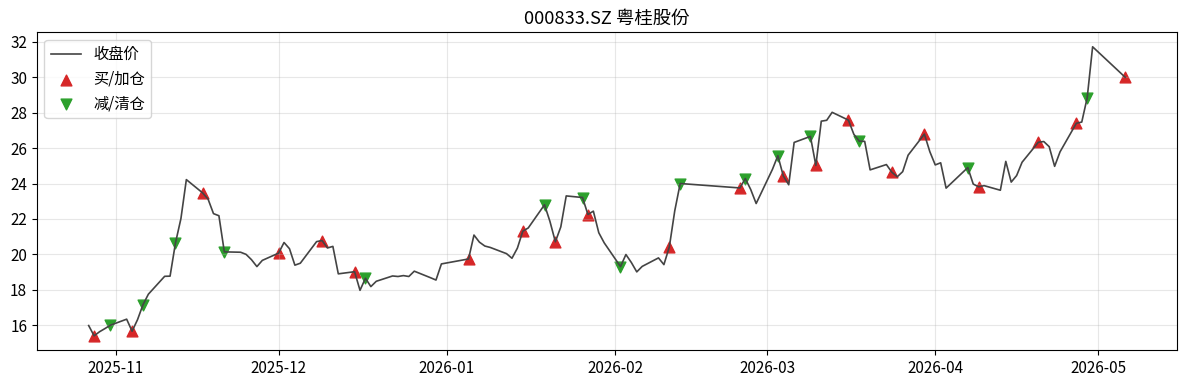

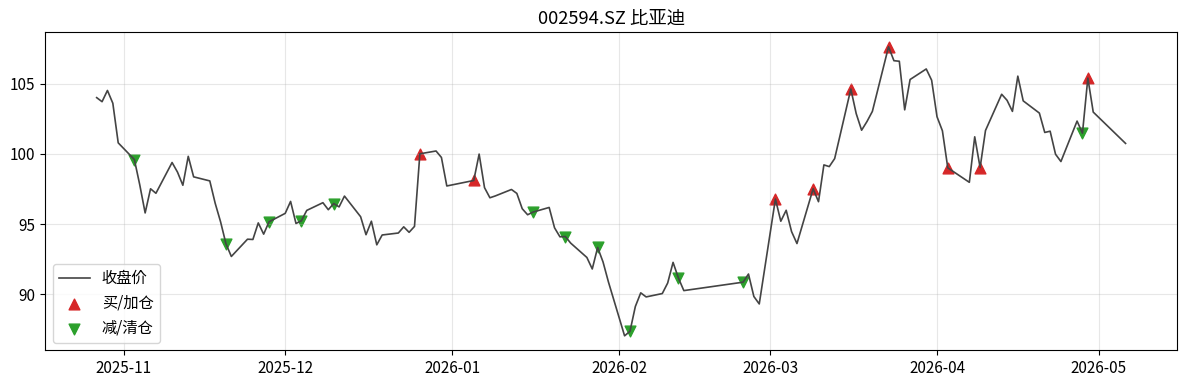

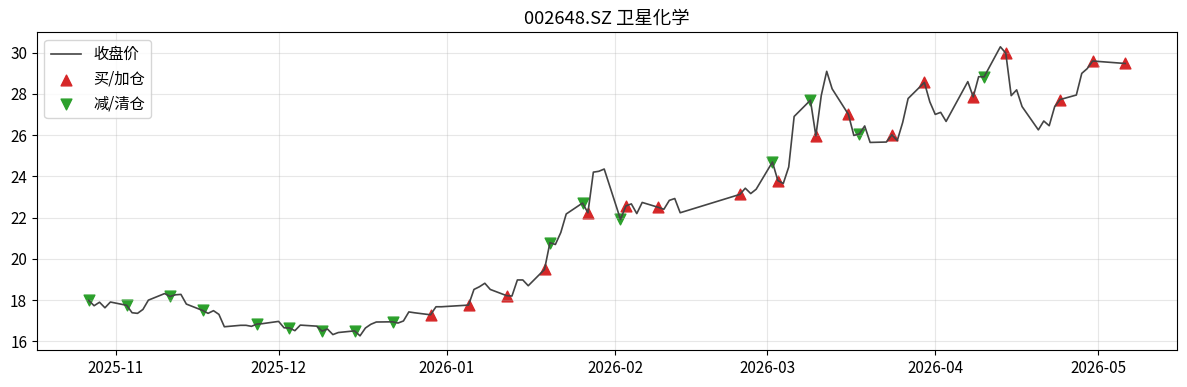

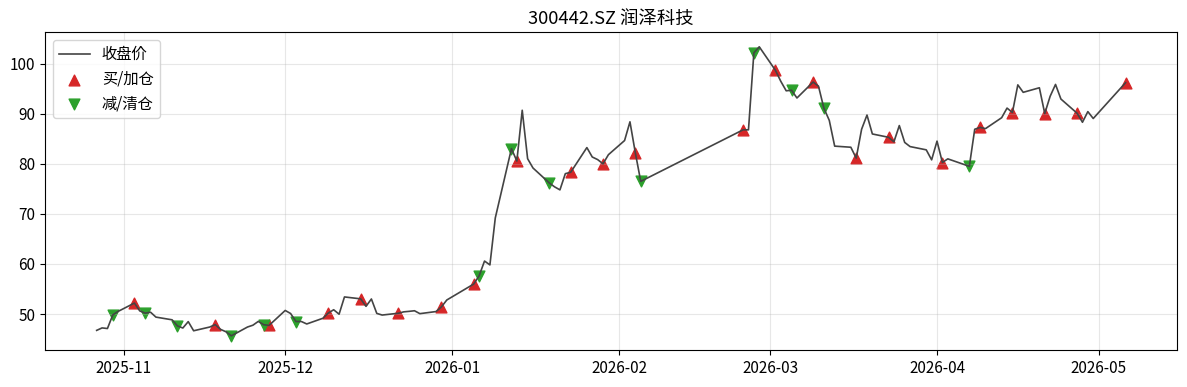

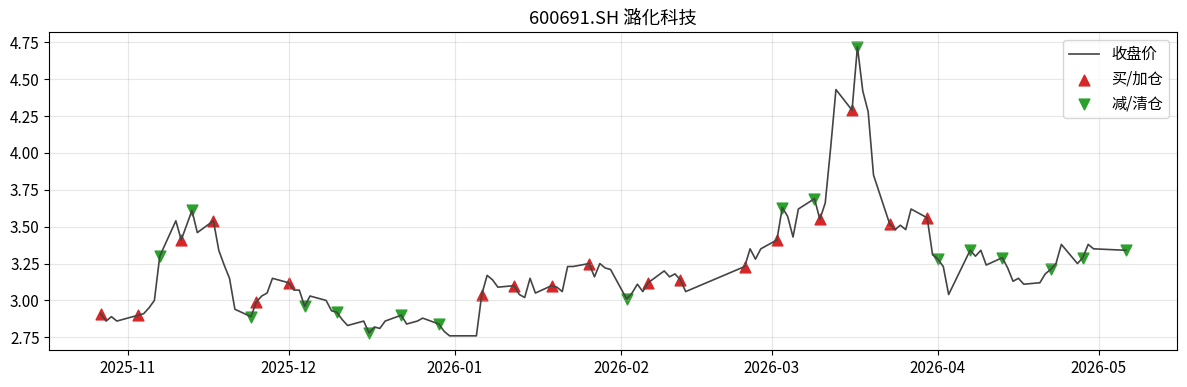

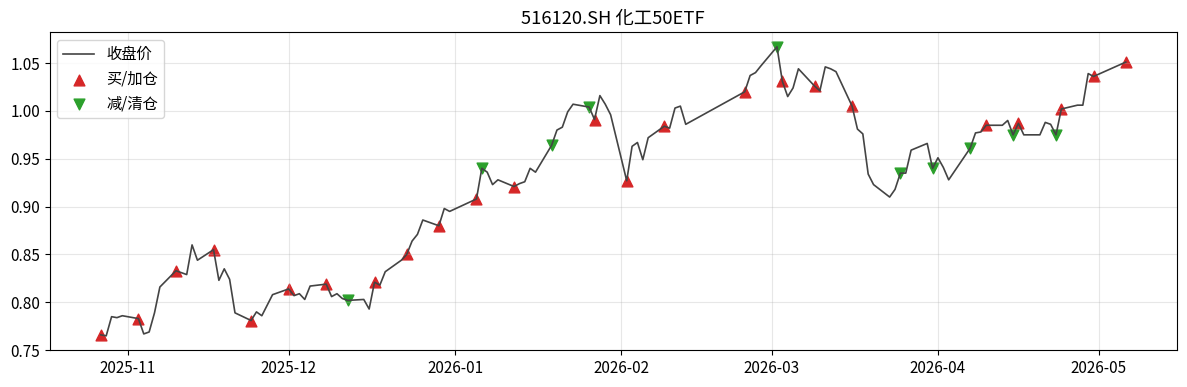

In [25]:
from invest_model.advisor.persistence import get_advisor_history

PLOT_DAYS = 120
_start = pd.to_datetime(trade_date, format='%Y%m%d') - pd.Timedelta(days=PLOT_DAYS * 1.6)
_start_str = _start.strftime('%Y%m%d')

history = get_advisor_history(engine, all_codes, _start_str, trade_date)

for code in all_codes:
    d = daily_repo.get_daily(code, _start_str, trade_date)
    if d.empty:
        d = etf_repo.get_daily(code, _start_str, trade_date)
    if d.empty:
        continue
    d = d.copy()
    d['date'] = pd.to_datetime(d['trade_date'], format='%Y%m%d')
    d['close'] = pd.to_numeric(d['close'], errors='coerce')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(d['date'], d['close'], color='#444', linewidth=1.2, label='收盘价')

    # 历史买卖标记
    if not history.empty:
        sub = history[history['code'] == code].copy()
        if not sub.empty:
            sub['date'] = pd.to_datetime(sub['trade_date'], format='%Y%m%d')
            sub = sub.merge(d[['date', 'close']], on='date', how='left')
            buys = sub[sub['action'].isin(['buy', 'strong_buy', 'add'])]
            sells = sub[sub['action'].isin(['reduce', 'clear'])]
            if not buys.empty:
                ax.scatter(buys['date'], buys['close'], marker='^', color='#d62728', s=60, label='买/加仓')
            if not sells.empty:
                ax.scatter(sells['date'], sells['close'], marker='v', color='#2ca02c', s=60, label='减/清仓')

    name = code_name_map.get(code, '')
    ax.set_title(f'{code} {name}'); ax.legend(loc='best'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 8. 写入数据库

In [26]:
n_saved = save_advisor_signals(engine, signals)
print(f'写入 {n_saved} 条 advisor 信号到 stock_advisor_signal')

写入 6 条 advisor 信号到 stock_advisor_signal
